In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score

In [2]:
X, y = make_classification(
    n_samples=1000,        # total samples
    n_features=10,         # total features
    n_informative=6,       # useful features
    n_redundant=2,         # redundant features
    n_classes=2,           # binary classification
    random_state=42
)

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1000, 10)
Target Shape: (1000,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (800, 10)
Test Size: (200, 10)


In [4]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.8


In [5]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.82


In [6]:
print("For Logistic Regression Model")
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(y_test, y_pred_log),columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision", precision_score(y_test, y_pred_log))
print("Recall", recall_score(y_test, y_pred_log))
print("F1 Score", f1_score(y_test, y_pred_log))

For Logistic Regression Model
--------------------------------------------------
    0   1
0  82  31
1   9  78
--------------------------------------------------
Precision 0.7155963302752294
Recall 0.896551724137931
F1 Score 0.7959183673469388


In [7]:
print("For Decision Tree Model")
print("-"*50)
cdf = pd.DataFrame(confusion_matrix(y_test, y_pred_dt),columns=list(range(0,2)))
print(cdf)
print("-"*50)
print("Precision", precision_score(y_test, y_pred_dt))
print("Recall", recall_score(y_test, y_pred_dt))
print("F1 Score", f1_score(y_test, y_pred_dt))

For Decision Tree Model
--------------------------------------------------
    0   1
0  86  27
1   9  78
--------------------------------------------------
Precision 0.7428571428571429
Recall 0.896551724137931
F1 Score 0.8125


## Multiclass Classification

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [9]:
X, y = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=6,
    n_redundant=2,
    n_classes=4,                 # Multiclass
    n_clusters_per_class=1,
    random_state=42
)

print("Dataset Shape:", X.shape)
print("Number of Classes:", len(np.unique(y)))

Dataset Shape: (1000, 10)
Number of Classes: 4


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [11]:
log_model = LogisticRegression(max_iter=1000)
dt_model = DecisionTreeClassifier(random_state=42)

log_model.fit(X_train, y_train)
dt_model.fit(X_train, y_train)


y_pred_log = log_model.predict(X_test)
y_pred_dt = dt_model.predict(X_test)

In [12]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n===== {model_name} Evaluation =====")
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    # Precision, Recall, F1 (macro for multiclass)
    precision = precision_score(y_test, y_pred, average='macro')
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (Macro): {precision:.4f}")
    print(f"Recall (Macro): {recall:.4f}")
    print(f"F1 Score (Macro): {f1:.4f}")
    
    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()


===== Logistic Regression Evaluation =====
Accuracy: 0.7950
Precision (Macro): 0.7986
Recall (Macro): 0.8050
F1 Score (Macro): 0.7913

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.59      0.69        56
           1       0.65      0.85      0.74        41
           2       0.89      0.84      0.86        57
           3       0.81      0.93      0.87        46

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.79       200
weighted avg       0.81      0.80      0.79       200



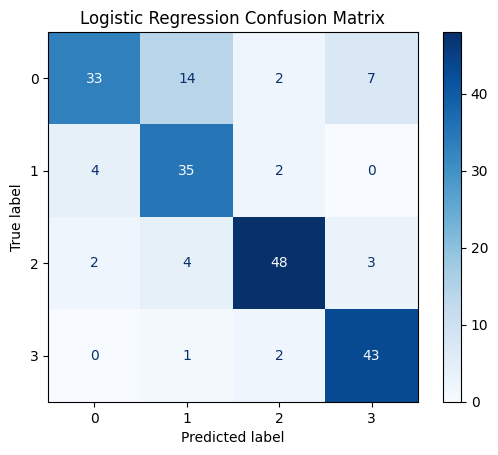


===== Decision Tree Evaluation =====
Accuracy: 0.8200
Precision (Macro): 0.8199
Recall (Macro): 0.8260
F1 Score (Macro): 0.8182

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.71      0.78        56
           1       0.72      0.88      0.79        41
           2       0.91      0.84      0.87        57
           3       0.78      0.87      0.82        46

    accuracy                           0.82       200
   macro avg       0.82      0.83      0.82       200
weighted avg       0.83      0.82      0.82       200



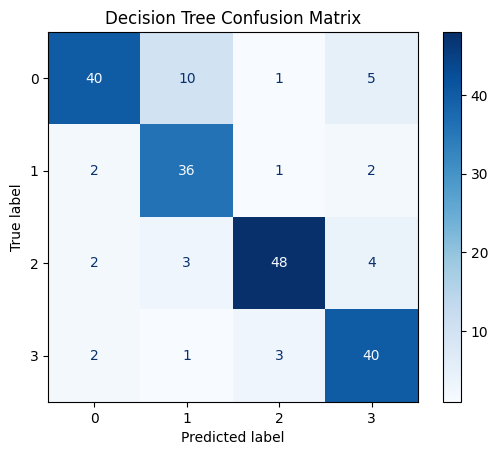

In [13]:
evaluate_model(y_test, y_pred_log, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")

In [14]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt)
    ],
    "Precision (Macro)": [
        precision_score(y_test, y_pred_log, average='macro'),
        precision_score(y_test, y_pred_dt, average='macro')
    ],
    "Recall (Macro)": [
        recall_score(y_test, y_pred_log, average='macro'),
        recall_score(y_test, y_pred_dt, average='macro')
    ],
    "F1 Score (Macro)": [
        f1_score(y_test, y_pred_log, average='macro'),
        f1_score(y_test, y_pred_dt, average='macro')
    ]
})

print("\n===== Model Comparison =====")
print(results)


===== Model Comparison =====
                 Model  Accuracy  Precision (Macro)  Recall (Macro)  \
0  Logistic Regression     0.795           0.798628        0.804958   
1        Decision Tree     0.820           0.819885        0.826001   

   F1 Score (Macro)  
0          0.791283  
1          0.818248  
